<a href="https://colab.research.google.com/github/Text-Machine/mask-predict/blob/main/example_analysis_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/> </a>

When running this notebook from Colab, you need to run the following cells to download the data and install the explain package.

In [ ]:
!gdown --folder 1DEtOJg4NmJok40MHje68N-K-JPPm1bfD
!mv /content/ExperimentsData/* .
!rm -r /content/ExperimentsData

In [26]:
!git clone https://github.com/Text-Machine/mask-predict.git

Cloning into 'mask-predict'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 108 (delta 61), reused 78 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (108/108), 113.64 KiB | 4.06 MiB/s, done.
Resolving deltas: 100% (61/61), done.


In [ ]:
%cd mask-predict

In [ ]:
!pip install -q -e .

# Contrastive Analysis of Masked Tokens

In [1]:
import pandas as pd
import json
from tqdm import tqdm
from explain import *
from pathlib import Path

## A note on data, variable names and terminology

### A contrastive analysis masked tokens?

What we pursue is **contrastive analysis** of two different concepts, captured by two distinct set of tokens. For example, the concept 'machine' is captured by 'machine' and 'machines', the contrastive concept is 'slave'.
- Note: I suggest to replace the bidrectional or reverse masking with contrastive analysis.

### Axis 1: Target vs. Contrastive Concept

One of the concepts is the **"target concept"**, to other one the **"contrastive concept"**. Each analysis starts with a target concept or token, or `TargetMaskedToken`, this is the starting point of the analysis, for example the word 'machine'. This tokens has two associated datasets. 
    - a TargetMaskedToken maps onto a set of workds that capture the target concept
    - sentences which contain the masked token (`df_target_sent`)
    - contribution obtained by from the integrated gradients method (abbr "ig", `df_target_ig`) 

The `TargetMaskedToken` related to a `ContrastiveMaskedToken`, in this case the word slave. Similary, the contrastive concepts is associated with a set of sentences that contain the tokens expressing the target concept.


### Axis 2: Observed vs. Counterfactual Language Use

To understand language model predictions, we study both the `TargetMaskedToken` and the `ContrastiveMaskedToken` in two scenarios: **observed** and **counterfactual**. 

 Observed refers to scenarios in which the target of constrastive token appears in the sentences. We than look what tokens contribute to predicting the actual word use. In counterfactual scenarios, we 

 For more target and constrastive concepts map **inversely** to observed and counterfactual tokens, i.e. when the `target` is machine, and the contrastive concept is `slave`, then when analysis machine sentences, the observed tokens are 'machine' and 'machines' and the counterfactual ones are 'slave' and 'slaves'.


In [2]:
collection,genre_suffix = 'blb',''
if collection == 'blb':
  genre_suffix = '_with_genre'

TargetMaskedToken = 'machine' # the token to be masked in the target sentence
ContrastiveMaskedToken = 'slave' # the contrastive token to be masked in the sentence
dataPath = 'masking_data' # change to '.' when working in colab 
processedFolder = 'processed_data' # change '.' when working in colab
predCol = "pred_bert_1760_1900"

print(f"This analysis focuses on '{TargetMaskedToken}' which we constrast to '{ContrastiveMaskedToken}'.")

This analysis focuses on 'machine' which we constrast to 'slave'.


In [3]:
mask2tokens = {'machine':['machine', 'machines'], 'slave':['slave', 'slaves']}

### Only for Colab: Unzipping downloaded data

In [ ]:
!unzip -o "/content/{collection}_{TargetMaskedToken}_clusters{genre_suffix}.tsv.zip"
!unzip -o "/content/results_{collection}_{TargetMaskedToken}_constrastive.csv.zip"
!unzip -o "/content/{collection}_{ContrastiveMaskedToken}_clusters{genre_suffix}.tsv.zip"
!unzip -o "/content/results_{collection}_{ContrastiveMaskedToken}_constrastive.csv.zip"

## Loading the Sentences in IG Data as DataFrames

In [177]:
# load the original sentences with the predicted tokens
df_target_sent = pd.read_csv(f'{dataPath}/{collection}_{TargetMaskedToken}_clusters{genre_suffix}.tsv', index_col=0, sep='\t')
print(f'We have {df_target_sent.shape[0]} sentences for the target token {TargetMaskedToken}.')
# load the data with the constrastive explanations
df_target_ig = pd.read_csv(f'{processedFolder}/results_{collection}_{TargetMaskedToken}_constrastive.csv', index_col=0 )
print(f'We have {df_target_ig.shape[0]} explanations for the target token {TargetMaskedToken}.')

We have 131002 sentences for the target token machine.
We have 11008832 explanations for the target token machine.


In [178]:
df_target_sent['sent_clean'] = df_target_sent['currentSentence'].apply(lambda x: ''.join([ch.lower() for ch in x if ch.isalpha()]))
print(f'Before cleaning the sentences, we have {df_target_sent.shape[0]} sentences and {df_target_ig.shape[0]} gradients for the target token {TargetMaskedToken}.')
df_target_sent.drop_duplicates(subset=['sent_clean'], keep='first', inplace=True)
df_target_ig = df_target_ig[df_target_ig['id'].isin(df_target_sent.index)]
print(f'After cleaning the sentences, we have {df_target_sent.shape[0]} sentences and {df_target_ig.shape[0]} gradients for the target token {TargetMaskedToken}.')


Before cleaning the sentences, we have 131002 sentences and 11008832 gradients for the target token machine.
After cleaning the sentences, we have 77907 sentences and 6666264 gradients for the target token machine.


In [74]:
# load the original sentences with the predicted tokens
df_contrastive_sent = pd.read_csv(f'{dataPath}/{collection}_{ContrastiveMaskedToken}_clusters{genre_suffix}.tsv', index_col=0, sep='\t')
print(f'We have {df_contrastive_sent.shape[0]} sentences for the contrastive token {ContrastiveMaskedToken}.')

# load the data with the constrastive explanations
df_contrastive_ig = pd.read_csv(f'{processedFolder}/results_{collection}_{ContrastiveMaskedToken}_constrastive.csv', index_col=0 )
print(f'We have {df_contrastive_ig.shape[0]} explanations for the contrastive token {ContrastiveMaskedToken}.')

We have 53727 sentences for the contrastive token slave.
We have 4625482 explanations for the contrastive token slave.


In [179]:
df_contrastive_sent['sent_clean'] = df_contrastive_sent['currentSentence'].apply(lambda x: ''.join([ch.lower() for ch in x if ch.isalpha()]))
print(f'Before cleaning the sentences, we have {df_contrastive_sent.shape[0]} sentences and {df_contrastive_ig.shape[0]} gradients for the target token {TargetMaskedToken}.')
df_contrastive_sent.drop_duplicates(subset=['sent_clean'], keep='first', inplace=True)
df_contrastive_ig = df_contrastive_ig[df_contrastive_ig['id'].isin(df_contrastive_sent.index)]
print(f'After cleaning the sentences, we have {df_contrastive_sent.shape[0]} sentences and {df_contrastive_ig.shape[0]} gradients for the target token {TargetMaskedToken}.')


Before cleaning the sentences, we have 53727 sentences and 4625482 gradients for the target token machine.
After cleaning the sentences, we have 48827 sentences and 4239592 gradients for the target token machine.


In [180]:
df_target_ig['Score_normalized'] = df_target_ig.groupby('id')['Score'].transform(
    lambda x: x / x.abs().sum() if x.abs().sum() > 0 else x
)

In [181]:
df_target_ig['Sentence_length'] = df_target_ig.groupby('id')['Score'].transform(
    lambda x: len(x)
)

In [182]:
df_contrastive_ig['Score_normalized'] = df_contrastive_ig.groupby('id')['Score'].transform(
    lambda x: x / x.abs().sum() if x.abs().sum() > 0 else x
)

In [183]:
df_contrastive_ig['Sentence_length'] = df_contrastive_ig.groupby('id')['Score'].transform(
    lambda x: len(x)
)

In the following cells we inspect the output, you can skip these.

In [184]:
# inspect the data
# each sentence appears twice, once for the original masked token, (Target=maskedtoken) and once for the contrastive token (Target=contrastive)
# i.e. if masked token is 'machine' then contrastive token is 'slave'
df_target_ig.head()

,Token,Score,Target,id,Score_normalized,Sentence_length
0,the,0.055053,machine,60000,0.015723,44
1,[MASK],0.000000,machine,60000,0.000000,44
2,shops,0.330447,machine,60000,0.094376,44
3,occupy,-0.067776,machine,60000,-0.019357,44
4,three,0.071201,machine,60000,0.020335,44


In [185]:
df_contrastive_ig.head()

,Token,Score,Target,id,Score_normalized,Sentence_length
0,the,0.090441,machine,0,0.011061,100
1,greeks,0.130847,machine,0,0.016002,100
2,owe,-0.023468,machine,0,-0.002870,100
3,their,0.082341,machine,0,0.010070,100
4,letters,0.084634,machine,0,0.010351,100


In [186]:
df_contrastive_ig[df_contrastive_ig['id'] == 0].shape

(100, 6)

In [187]:
# inspect alignment of sentences between dataframes df_sentences and results_df
idx = df_target_sent.shape[0] -2
list(df_target_ig[df_target_ig.id == idx].Token)[:5],df_target_sent.iloc[idx].maskedSentence

(['man', ',', 'the', '[MASK]', 'of'],
 'You would fain be thought to take no share in government , while in reality you are tho main spring of the [MASK] .')

In [188]:
# Note: there is a tiny bug, I forgot the process the last sentence of df_sentences
df_target_ig['id'].nunique(),len(df_target_sent)

(77906, 77907)

# Macro-Scale Influences

At the level of all sentences containing the masked token, which words influence the prediction of observed (or counter-factual) terms.

Why is this interesting?
- **validation**: partly shows that the method works, e.g. the words that influence the prediction of the actual masked token word 'machine' should make sense.
- **counterfactual**: highlight which words in the context of x ('machine') are associated with contrastive term y ('slave'), e.g. which words in the context of machine do contribute to the prediction of slavery, foreground intermingling of two discourses?


## 🛎️ Important 🛎️

In the next cell, decide if you want to analyse the target of contrastive concept.

In [189]:
decision = 'target' # choose whether to analyze the target token or the contrastive token, options: 'target' or 'contrastive'

Based on the `decision` variable we select the correct associated data.

In [190]:
if decision == 'target':
    df_ig = df_target_ig
    df_sent = df_target_sent
elif decision == 'contrastive':
    df_ig = df_contrastive_ig
    df_sent = df_contrastive_sent
else:
    raise ValueError("Invalid decision. Please choose 'target' or 'contrastive'.")
print(f"Analyzing the '{decision}' token '{TargetMaskedToken if decision == 'target' else ContrastiveMaskedToken}': {df_ig.shape[0]} explanations and {df_sent.shape[0]} sentences.")

Analyzing the 'target' token 'machine': 6666264 explanations and 77907 sentences.


In [191]:
# divide results_df into two dataframes, one for the masked token and one for the contrastive token, and calculate the average score for each token in each dataframe
min_sent_length = 25 # threshold to filter out sentences that are too short
df_observed_ig = df_ig[
                (df_ig['Target'].isin(mask2tokens[TargetMaskedToken])) & (df_ig['Sentence_length'] > min_sent_length)
                       ].groupby('Token').agg(avg=('Score_normalized', 'mean'), count=('Score', 'size'), std=('Score_normalized', 'std'))
df_counterfactual_ig = df_ig[
                (df_ig['Target'].isin(mask2tokens[ContrastiveMaskedToken])) & (df_ig['Sentence_length'] > min_sent_length)
                             ].groupby('Token').agg(avg=('Score_normalized', 'mean'), count=('Score', 'size'), std=('Score_normalized', 'std'))

In [192]:
# just to check, the number rows should be identical
df_observed_ig.shape, df_counterfactual_ig.shape

((73744, 3), (73744, 3))

In [193]:
min_freq = 10 # how often should the token appear in the explanations to be included in the analysis
top_n = 10 # how many tokens to show in the top list
print(f"Top {top_n} tokens with the highest average score for the '{decision}' token '{TargetMaskedToken if decision == 'target' else ContrastiveMaskedToken}'.\nOnly showing tokens that appear at least {min_freq} times in the explanations:")
df_observed_ig[df_observed_ig['count'] > min_freq
                ].sort_values('avg', ascending=False
                              ).head(top_n)[['avg', 'count', 'std']]

Top 10 tokens with the highest average score for the 'target' token 'machine'.
Only showing tokens that appear at least 10 times in the explanations:


,avg,count,std
Token,,,
sewing,0.092919,2338,0.047558
bathing,0.081751,1717,0.050149
dredging,0.079800,341,0.030890
voting,0.072990,17,0.043306
electrifying,0.072012,63,0.033322
calculating,0.071746,180,0.049306
threshing,0.071529,1219,0.033832
administrative,0.070869,61,0.042894
thrashing,0.069658,629,0.040035


In [194]:
# show the top contributors to the prediction of the masked token 'slave' (or 'slaves')
print(f"Top {top_n} tokens with the highest average score for the '{'contrastive' if decision == 'target' else 'target'}' token '{ContrastiveMaskedToken if decision == 'target' else TargetMaskedToken}'.\nOnly showing tokens that appear at least {min_freq} times in the explanations:")
df_counterfactual_ig[df_counterfactual_ig['count'] > min_freq
                ].sort_values('avg', ascending=False
                              ).head(top_n)[['avg', 'count', 'std']]

Top 10 tokens with the highest average score for the 'contrastive' token 'slave'.
Only showing tokens that appear at least 10 times in the explanations:


,avg,count,std
Token,,,
pendulum,0.054537,27,0.051973
unoiled,0.052803,33,0.035055
infernal,0.052732,967,0.025898
typewriter,0.052197,11,0.044890
bureaucratic,0.051838,12,0.022950
ry,0.050282,106,0.054593
corpse,0.047097,11,0.049630
threshing,0.046304,1219,0.033711
bosses,0.046214,12,0.046626


In [198]:
context_token = 'pendulum'
ids = df_ig[(df_ig['Token'] == context_token)]['id']
sentences_with_context_token = df_ig[df_ig['id'].isin(ids) & df_ig['Target'].isin(mask2tokens[TargetMaskedToken])
                                     ].groupby('id')['Token'].apply(lambda x: ' '.join(x))#.reset_index(name='sentence')
[sentence for sentence in sentences_with_context_token.values]

['the effect of the [MASK] is found from the relations between the weight and dimensions of the pendulum to the dimensions',
 'the effect of the [MASK] is found from the relations between the weight and dimensions of the pendulum to the dimensions 488 petroleum . of the testing journal and the pressure of the helical spring ex - erted upon the latter .',
 'to determine the lubricating quality of an oil with this [MASK] , remove the pendulum h h from the testing journal 490 petroleum .',
 'then carefully slide the pendulum upon the testing journal , oil the journal through the oil cups , and set the [MASK] in motion , running it a moment , until the oil is well distributed over the journal .',
 'the pendulum of the [MASK] carries an arm with a horizontal bolt on its extreme end .',
 "he measured the vibrations of a pendulum two hundred feet long attached to the steeple of st . paul ' s ; invented a useful [MASK] for cutting the teeth of watch wheels ; fixed the thermo metrical zero at t

# Inspect specific token contributions by sentence

Based on these overall contributions, you can select context words and investigate how they interact with slave and machine in concrete sentences.

In [53]:
modelName = "Livingwithmachines/bert_1760_1900"
explainer = MaskedLMExplainer(model_name=modelName, device=pick_device())

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: Livingwithmachines/bert_1760_1900
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [199]:
# get the ids for the sentences containing the context token 'tentering' and the masked tokens 'slave' or 'slaves'
context_token = 'pendulum' 
masked_tokens = mask2tokens[ContrastiveMaskedToken]
print(masked_tokens)
df_ig[(df_ig.Token==context_token) & (df_ig.Target.isin(masked_tokens))]['id'].unique()

['slave', 'slaves']


array([ 66112,  68300,  73222,  77589,  78551,  40830,  48404,  49079,
        49085,  57712,  21262,  28786,  36950, 108594, 117449,   5674,
         5678,   5681,   5682,   5687,  12079,  12751,  14757,  80347,
        86229,  87683,  90870,  92788])

In [200]:
# select one of the above ids and highlight the context tokens in the sentence
idx = 68300
sentence = ' '.join(df_ig[(df_ig.id==idx) & df_ig.Target.isin(masked_tokens)]['Token'].values)
target = df_ig[(df_ig.id==idx) & df_ig.Target.isin(masked_tokens)]['Target'].values[0]
highlight_context_tokens(explainer, sentence, target=target, word_agg="mean")

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

'\n    <div id="tokviz_a7c882921d77479aaa7c65a6693e08c6">\n      <div style=\'margin-bottom:6px;\'>\n        <b>Target:</b> <code>slave</code>\n      </div>\n      <div style=\'margin:6px 0 10px 0; font-size:13px; display:flex; gap:10px; align-items:center;\'>\n        <span style=\'background:rgba(30,136,229,0.35); padding:2px 8px; border-radius:4px;\'>&#9646; predicts</span>\n        <span style=\'background:rgba(229,57,53,0.35);  padding:2px 8px; border-radius:4px;\'>&#9646; opposes</span>\n        <span style=\'background:rgba(255,193,7,0.85);  padding:2px 8px; border-radius:4px; font-weight:bold;\'>[target] mask position</span>\n      </div>\n      <div style=\'line-height:2.4; font-size:15px;\'>\n        <span class=\'tok\' data-score=\'0.000495\' style=\'background:rgba(30, 136, 229, 0.101); padding:2px 4px; margin:1px; border-radius:4px; cursor:default;\'>there</span> <span class=\'tok\' data-score=\'-0.040466\' style=\'background:rgba(229, 57, 53, 0.172); padding:2px 4px; marg

# Macro-level differences between actual and counterfactual masked tokens


Previous analysis shows contributions for each masked tokens (actual and counterfactual). However, some words might contribute equally to both masked target words.

Therefore we now focus on differences (the contrast): i.e. which words are most associated with either 'slave' or 'machine'.

In [201]:
df_observed_ig_tok = df_ig[(df_ig['Target'].isin(mask2tokens[TargetMaskedToken]))].reset_index(drop=True)
df_counterfactual_ig_tok = df_ig[(df_ig['Target'].isin(mask2tokens[ContrastiveMaskedToken]))].reset_index(drop=True)

In [202]:
df_observed_ig_tok['Diff_Obs_Counter_Score'] = df_observed_ig_tok['Score_normalized'] - df_counterfactual_ig_tok['Score_normalized']
df_observed_ig_tok['Counter_Score'] = df_counterfactual_ig_tok['Score_normalized']
diff = df_observed_ig_tok.groupby('Token').agg(avg_diff=('Diff_Obs_Counter_Score', 'mean'), count=('Diff_Obs_Counter_Score', 'size'), std_diff=('Diff_Obs_Counter_Score', 'std'), target_scores=('Score_normalized', 'mean'), counter_scores=('Counter_Score', 'mean'))#.sort_values('avg_diff', ascending=False).head(10)

In [203]:
print(f"Top {top_n} tokens with the highest average difference in scores between the '{decision}' token '{TargetMaskedToken if decision == 'target' else ContrastiveMaskedToken}' and the '{'contrastive' if decision == 'target' else 'target'}' token '{ContrastiveMaskedToken if decision == 'target' else TargetMaskedToken}'.\nOnly showing tokens that appear at least {min_freq} times in the explanations:")
print("Showing the words most leaning to '{}'.".format(TargetMaskedToken if decision == 'target' else ContrastiveMaskedToken))
diff[diff['count'] > 10].sort_values('avg_diff', ascending=False).head(top_n)

Top 10 tokens with the highest average difference in scores between the 'target' token 'machine' and the 'contrastive' token 'slave'.
Only showing tokens that appear at least 10 times in the explanations:
Showing the words most leaning to 'machine'.


,avg_diff,count,std_diff,target_scores,counter_scores
Token,,,,,
sewing,0.078579,2436,0.057819,0.095837,0.017258
bathing,0.071537,1770,0.054072,0.083033,0.011496
dredging,0.064408,348,0.034270,0.081323,0.016914
administrative,0.053867,61,0.046009,0.070869,0.017002
explosive,0.053630,52,0.084309,0.047305,-0.006325
calculating,0.053532,188,0.055957,0.073645,0.020113
filtering,0.051244,26,0.046289,0.065330,0.014086
crashing,0.050204,23,0.055421,0.037816,-0.012389
voting,0.049000,17,0.056356,0.072990,0.023990


In [204]:
print("Showing the words most leaning to '{}'.".format(ContrastiveMaskedToken if decision == 'target' else TargetMaskedToken))
diff[diff['count'] > 10].sort_values('avg_diff', ascending=True).head(top_n)

Showing the words most leaning to 'slave'.


,avg_diff,count,std_diff,target_scores,counter_scores
Token,,,,,
superiors,-0.035846,11,0.040685,-0.007132,0.028713
rib,-0.032560,20,0.043362,0.001955,0.034516
buckle,-0.025577,15,0.056347,-0.004603,0.020973
pulse,-0.020402,106,0.022839,-0.001883,0.018519
centrifugal,-0.019015,146,0.036825,0.025753,0.044768
wolf,-0.017794,16,0.035008,0.006011,0.023806
swayed,-0.016930,12,0.031460,-0.008630,0.008300
thief,-0.016785,13,0.033030,0.006939,0.023724
trophies,-0.016374,14,0.047979,0.008794,0.025168


In [206]:
context_token = 'superiors'
ids = df_ig[(df_ig['Token'] == context_token)]['id']
sentences_with_context_token = df_ig[df_ig['id'].isin(ids) & df_ig['Target'].isin(mask2tokens[TargetMaskedToken])
                                     ].groupby('id')['Token'].apply(lambda x: ' '.join(x))#.reset_index(name='sentence')
[sentence for sentence in sentences_with_context_token.values]

['the french soldier is not a mere [MASK] in the eyes of his superiors .',
 'he sees his superiors carried about in [MASK] , and imagines that in one of these he could travel with less inconveniency .',
 'he sees his superiors carried about in [MASK] , and imagines tbat in one of these he could travel with less inconveniency .',
 'he is patient under privations , submissive to his superiors , a strict disciplinarian , and no ill treatment , no danger , can deter him from perform ing his duty to his tzar and his country , — a [MASK] that can 326 turkey , russia , be employed for any purpose , and so insensible to fear , that if a sentinel falls at his feet from the bullet of a circassian , another immediately takes his place with the regularity of clock work .',
 'again , they are not treated as mere [MASK] by their superiors .',
 'they are considered as mere [MASK] , subordinate to the will , and born to defend the prerogatives of their superiors .',
 'they felt that the people who mad

# Sentence-level differences

For which sentences do we observe the largest shift in context contribution when switching between different target words?

Shifts are often largest for shorter sentences. Therefore, I added threshold to include only sentence above a certain tokens length.

In [207]:
diff_dict = {'slave':'machine', 'slaves':'machines','machine':'slave', 'machines':'slaves'}


In [208]:
df_observed_ig_tok['distance'] = df_observed_ig_tok.apply(lambda x: abs(x.Score - x.Counter_Score), axis=1)

In [209]:
min_length = 20 # threshold to filter out sentences that are too short 
top_n = 10 # show the top n sentences with the highest average difference in scores between the masked token and the contrastive token
by_sent = df_observed_ig_tok.groupby('id').agg(avg_diff=('Diff_Obs_Counter_Score', 'mean'),avg_dist=('distance', 'mean'), avg_target=('Score_normalized', 'mean'), count=('Diff_Obs_Counter_Score', 'size'))#
print(f"Top {top_n} sentences with the highest average difference in scores when changing the mask from the '{decision}' token '{TargetMaskedToken if decision == 'target' else ContrastiveMaskedToken}' and the '{'contrastive' if decision == 'target' else 'target'}' token '{ContrastiveMaskedToken if decision == 'target' else TargetMaskedToken}'.\nOnly showing sentences that have at least {min_length} tokens in the explanations:")
by_sent[by_sent['count'] > min_length].sort_values('avg_diff', ascending=False).head(top_n)

Top 10 sentences with the highest average difference in scores when changing the mask from the 'target' token 'machine' and the 'contrastive' token 'slave'.
Only showing sentences that have at least 20 tokens in the explanations:


,avg_diff,avg_dist,avg_target,count
id,,,,
63454,0.040363,0.119138,0.037569,22
61671,0.040234,0.156374,0.042379,22
2236,0.038865,0.144606,0.025817,22
93656,0.038782,0.130448,0.039650,21
102094,0.037257,0.095621,0.039285,22
80906,0.037123,0.164426,0.039739,23
23798,0.036739,0.088547,0.040257,21
85630,0.036654,0.107269,0.039859,21
58569,0.036404,0.132381,0.039026,22


<Axes: xlabel='avg_target', ylabel='count'>

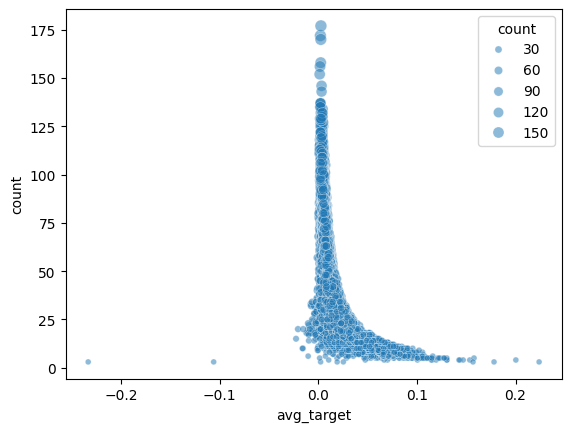

In [210]:
import seaborn as sns
sns.scatterplot(data=by_sent, x='avg_target', y='count', size='count', alpha=0.5)

In [211]:
by_sent[(by_sent['avg_dist'].between(0.0,0.1)) & (by_sent['count'] > 10)].sort_values('avg_dist', ascending=True).head(top_n)

,avg_diff,avg_dist,avg_target,count
id,,,,
106474,-0.001308,0.002209,0.004234,47
7651,0.003275,0.002342,0.002879,102
67828,0.000801,0.002392,0.003616,107
73463,-0.000585,0.002687,0.004314,73
122198,-0.000261,0.002838,0.003704,84
103940,0.000918,0.002894,0.002943,111
32828,0.005496,0.002935,0.010624,47
73535,0.001766,0.003047,0.006000,80
53072,0.001865,0.003078,0.007102,57


In [212]:
by_sent[(by_sent['avg_diff'].between(0.0,0.1)) & (by_sent['count'] > 10)].sort_values('avg_diff', ascending=True).head(top_n)

,avg_diff,avg_dist,avg_target,count
id,,,,
91315,1.448696e-08,0.056688,0.007529,61
122134,4.764418e-07,0.015326,0.005264,59
58556,6.633015e-07,0.102018,0.010607,37
39078,1.111726e-06,0.035915,0.006846,66
39743,1.115342e-06,0.015760,0.004936,93
122636,1.142317e-06,0.082393,0.006162,49
41164,1.364604e-06,0.048042,0.006667,52
97962,1.467082e-06,0.012543,0.005311,86
6765,2.039784e-06,0.007880,0.006159,55


In [213]:
# by_sent[(by_sent['avg_diff'].between(-.1, .1)) & (by_sent['avg_dist'] > 0.25) & (by_sent['count'] > 10)].sort_values('avg_dist', ascending=False).head(top_n)

In [214]:
#df_observed_ig_tok[df_observed_ig_tok['id']==15573][['Token', 'Score', 'Counter_Score', 'Diff_Obs_Counter_Score', 'distance']]

In [215]:
modelName = "Livingwithmachines/bert_1760_1900"
explainer = MaskedLMExplainer(model_name=modelName, device=pick_device())

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: Livingwithmachines/bert_1760_1900
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [216]:
by_sents = by_sent[(by_sent['avg_dist'].between(0.0,0.01)) & (by_sent['count'] > 10)].sort_values('avg_dist', ascending=True).head(top_n).reset_index()
#by_sents =by_sent[(by_sent['avg_diff'].between(0.0,0.1)) & (by_sent['count'] > 10)].sort_values('avg_diff', ascending=True).head(top_n).reset_index()
sentences = [(idx,
              ' '.join(df_ig[(df_ig.id==idx) & df_ig.Target.isin(mask2tokens[TargetMaskedToken])]['Token'].values),
              df_ig[(df_ig.id==idx) & df_ig.Target.isin(mask2tokens[TargetMaskedToken])]['Target'].values[0]
              ) for idx in by_sents['id']]
sentences


[(106474,
  'one would think the weavers would have been glad to get their threads spun so much more quickly ; but no : they said hargreave would spoil their trade ; 52 the forty shires . they broke his [MASK] , and drove him from his home .',
  'machine'),
 (7651,
  'there are now four general stores , two drug stores , one furniture store , one hardware and tin shop , one book store , four blacksmiths , four shoemakers , two harness makers , one wagon maker , three dress makers , two milliners , one tailor , one broom maker , one photographer , one marble cutter , one meat market , one poultry dealer , one paint shop and undertaker , one dealer in pumps and wind mills , one dentist , one dealer in farm machinery , one dealer in organs and sewing [MASK] , one saloon .',
  'machines'),
 (67828,
  "none of us could refrain from an occasional titter at the ab surdity of the solemn farce we were playing — fortunately , how ever , unheard by n . at length , nambo being turned out , and the

In [219]:
idx = 73463 # select one of the adove ids with a high average difference in scores between the masked token and the contrastive token
sentence = ' '.join(df_ig[(df_ig.id==idx) & df_ig.Target.isin(mask2tokens[TargetMaskedToken])]['Token'].values)
target = df_ig[(df_ig.id==idx) & df_ig.Target.isin(mask2tokens[TargetMaskedToken])]['Target'].values[0]
print(sentence, target)
highlight_context_tokens(explainer, sentence, target=target, word_agg="max")

" she is just the kind of person i wanted to be with , " kathleen said to barry , when he was once more bidding her farewell ; " she regards me as a mere [MASK] for imparting avhat she calls a fine taste to her daughters ; pleased as she is with my playing and painting , she sinks my humanity , and asks no ques tions about my antecedents . machine


Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

'\n    <div id="tokviz_70b43e530fe441c18910784d9e29cd4f">\n      <div style=\'margin-bottom:6px;\'>\n        <b>Target:</b> <code>machine</code>\n      </div>\n      <div style=\'margin:6px 0 10px 0; font-size:13px; display:flex; gap:10px; align-items:center;\'>\n        <span style=\'background:rgba(30,136,229,0.35); padding:2px 8px; border-radius:4px;\'>&#9646; predicts</span>\n        <span style=\'background:rgba(229,57,53,0.35);  padding:2px 8px; border-radius:4px;\'>&#9646; opposes</span>\n        <span style=\'background:rgba(255,193,7,0.85);  padding:2px 8px; border-radius:4px; font-weight:bold;\'>[target] mask position</span>\n      </div>\n      <div style=\'line-height:2.4; font-size:15px;\'>\n        <span class=\'tok\' data-score=\'0.002534\' style=\'background:rgba(30, 136, 229, 0.123); padding:2px 4px; margin:1px; border-radius:4px; cursor:default;\'>&quot;</span> <span class=\'tok\' data-score=\'0.007113\' style=\'background:rgba(30, 136, 229, 0.163); padding:2px 4px; m

In [220]:

highlight_context_tokens(explainer, sentence, target='slave', word_agg="max")

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

'\n    <div id="tokviz_fab81c46ca2743ea922b04fb77cebac1">\n      <div style=\'margin-bottom:6px;\'>\n        <b>Target:</b> <code>slave</code>\n      </div>\n      <div style=\'margin:6px 0 10px 0; font-size:13px; display:flex; gap:10px; align-items:center;\'>\n        <span style=\'background:rgba(30,136,229,0.35); padding:2px 8px; border-radius:4px;\'>&#9646; predicts</span>\n        <span style=\'background:rgba(229,57,53,0.35);  padding:2px 8px; border-radius:4px;\'>&#9646; opposes</span>\n        <span style=\'background:rgba(255,193,7,0.85);  padding:2px 8px; border-radius:4px; font-weight:bold;\'>[target] mask position</span>\n      </div>\n      <div style=\'line-height:2.4; font-size:15px;\'>\n        <span class=\'tok\' data-score=\'0.000244\' style=\'background:rgba(30, 136, 229, 0.102); padding:2px 4px; margin:1px; border-radius:4px; cursor:default;\'>&quot;</span> <span class=\'tok\' data-score=\'0.008146\' style=\'background:rgba(30, 136, 229, 0.181); padding:2px 4px; mar

# Overlapping contributors

Which words are strong predictors of the actual and counterfactual token?

Here we look at the top_n contributes for both 'machine' and 'slave' (which appear more than n_count times in the context of the maskedToken) and take the overlap between the top ranked predictors.

In [221]:
min_count = 25 # how often should token appear in the explanations to be included in the analysis of the top contributing tokens to the prediction of the masked token
top_n = 100 # look at top n contrastive tokens
top_observed_indices = df_observed_ig[df_observed_ig['count'] > min_count].sort_values('avg', ascending=False).head(top_n).index
top_counterfactual_indices = df_counterfactual_ig[df_counterfactual_ig['count'] > min_count].sort_values('avg', ascending=False).head(top_n).index
overlap_indices = top_observed_indices.intersection(top_counterfactual_indices)

In [222]:
print(f"Overlap among the top {top_n} contributors for the '{TargetMaskedToken}' and '{ContrastiveMaskedToken}' with at least {min_count} occurrences in the explanations:")
overlap_indices

Overlap among the top 100 contributors for the 'machine' and 'slave' with at least 25 occurrences in the explanations:


Index(['electrifying', 'threshing', 'thrashing', 'shop', 'dling', 'carding',
       'pendulum', 'electrical', 'guns', 'photographic', 'jigging', 'ry',
       'gun', 'copying', 'balloon', 'mowing', 'weighing', 'praying',
       'political', 'infernal', 'winnowing', 'bicycle', 'machine', 'reaping',
       'trical', 'organism', 'frail', 'blacksmith', 'unoiled', 'pan',
       'washing', 'cone', 'machines', 'camera', 'drill', 'bolting', 'press',
       'patent', 'fuses', 'mere', 'frame', 'hydraulic', 'crane', 'net',
       'dynamo', 'fan'],
      dtype='str', name='Token')

# Using Metadata and Cluster Scores

## Time

Here we focus on sentence published between start_year and end_year

In [223]:
start_year = 1890
end_year = 1900
selected_sentences = df_sent[df_sent['date'].between(start_year, end_year)].index

In [224]:
df_observed_ig_sel = df_ig[(df_ig['Target'].isin(mask2tokens[TargetMaskedToken])) & (df_ig['id'].isin(selected_sentences))].groupby('Token').agg(avg=('Score', 'mean'), count=('Score', 'size'), std=('Score', 'std'))
df_counterfactual_ig_sel = df_ig[(df_ig['Target'].isin(mask2tokens[ContrastiveMaskedToken])) & (df_ig['id'].isin(selected_sentences))].groupby('Token').agg(avg=('Score', 'mean'), count=('Score', 'size'), std=('Score', 'std'))


In [225]:
min_count = 10 # how often should token appear in the explanations to be included in the analysis of the top contributing
top_n = 10
print(f"Top {top_n} tokens with the highest average score for the '{ContrastiveMaskedToken if decision == 'target' else TargetMaskedToken}' in sentences from {start_year} to {end_year}.\nOnly showing tokens that appear at least {min_count} times in the explanations:")
df_counterfactual_ig_sel[df_counterfactual_ig_sel['count'] > min_count
                ].sort_values('avg', ascending=False
                              ).head(top_n)[['avg', 'count', 'std']]

Top 10 tokens with the highest average score for the 'slave' in sentences from 1890 to 1900.
Only showing tokens that appear at least 10 times in the explanations:


,avg,count,std
Token,,,
gun,0.312349,228,0.225698
cone,0.300286,14,0.276797
infernal,0.291367,280,0.154664
unoiled,0.290030,32,0.175183
copying,0.278339,16,0.213765
flying,0.265966,170,0.214127
soulless,0.264878,15,0.129289
machine,0.258398,598,0.205586
ruling,0.256604,13,0.255439


In [226]:
print(f"Top {top_n} tokens with the highest average score for the '{decision}' token '{TargetMaskedToken if decision == 'target' else ContrastiveMaskedToken}' in sentences from {start_year} to {end_year}.\nOnly showing tokens that appear at least {min_count} times in the explanations:")
df_observed_ig_sel[df_observed_ig_sel['count'] > min_count
                ].sort_values('avg', ascending=False
                              ).head(top_n)[['avg', 'count', 'std']]

Top 10 tokens with the highest average score for the 'target' token 'machine' in sentences from 1890 to 1900.
Only showing tokens that appear at least 10 times in the explanations:


,avg,count,std
Token,,,
dredging,0.494542,23,0.166775
sewing,0.489192,780,0.235486
bathing,0.451868,438,0.259403
gun,0.392640,228,0.226396
copying,0.387535,16,0.285425
cone,0.385299,14,0.278721
shops,0.367487,360,0.200181
threshing,0.360734,206,0.171818
bombs,0.351041,12,0.243621


## Cluster-based filtering

Let's focus only on the sentence that scored high for the 'slave' cluster in the df_sentences dataframe.

In [34]:
top_cl_sent = 1000
colName = 'slave_1760_1900'
selected_sentences = df_sent.sort_values(by=colName, ascending=False)[:top_cl_sent].index

In [35]:
df_target_ig_sel = df_ig[(df_ig['Target'].isin(mask2tokens[TargetMaskedToken])) & (df_ig['id'].isin(selected_sentences))].groupby('Token').agg(avg=('Score', 'mean'), count=('Score', 'size'), std=('Score', 'std'))
df_counterfactual_ig_sel = df_ig[(df_ig['Target'].isin(mask2tokens[ContrastiveMaskedToken])) & (df_ig['id'].isin(selected_sentences))].groupby('Token').agg(avg=('Score', 'mean'), count=('Score', 'size'), std=('Score', 'std'))


In [36]:
min_count = 10 # how often should token appear in the explanations to be included in the analysis of the top contributing
top_n = 10
print(f"Top {top_n} tokens with the highest average score for the '{ContrastiveMaskedToken if decision == 'target' else TargetMaskedToken}' in the top {top_cl_sent} sentences with the highest scores in '{colName}'.\nOnly showing tokens that appear at least {min_count} times in the explanations:")
df_counterfactual_ig_sel[df_counterfactual_ig_sel['count'] > min_count
                ].sort_values('avg', ascending=False
                              ).head(top_n)[['avg', 'count', 'std']]

Top 10 tokens with the highest average score for the 'slave' in the top 1000 sentences with the highest scores in 'slave_1760_1900'.
Only showing tokens that appear at least 10 times in the explanations:


,avg,count,std
Token,,,
servants,0.300256,22,0.227196
mere,0.299474,137,0.177209
soldier,0.288940,15,0.235589
beings,0.286983,18,0.243868
slave,0.261036,33,0.191857
hundred,0.256948,23,0.194793
human,0.251165,84,0.239230
work,0.236881,173,0.233282
soldiers,0.234227,17,0.159183


In [64]:
print(f"Top {top_n} tokens with the highest average score for the '{decision}' token '{TargetMaskedToken if decision == 'target' else ContrastiveMaskedToken}' in the top {top_cl_sent} sentences with the highest scores in '{colName}'.\nOnly showing tokens that appear at least {min_count} times in the explanations:")
df_observed_ig_sel[df_observed_ig_sel['count'] > min_count
                ].sort_values('avg', ascending=False
                              ).head(top_n)[['avg', 'count', 'std']]

Top 10 tokens with the highest average score for the 'target' token 'machine' in the top 1000 sentences with the highest scores in 'slave_1760_1900'.
Only showing tokens that appear at least 10 times in the explanations:


,avg,count,std
Token,,,
electrical,0.386584,17,0.180264
dredging,0.384913,22,0.152761
shaft,0.376188,12,0.308198
hydraulic,0.342299,38,0.221731
pump,0.331008,14,0.281246
political,0.313466,46,0.217951
pan,0.307325,11,0.234481
engines,0.305669,33,0.214215
threshing,0.299179,19,0.176211


# Fin.